# Argentine RMA Radar — BUFR Format

This notebook demonstrates reading Argentine RMA (Radares Meteorologícos Argentinos) radar data from the RELAMPAGO field campaign (November 2018) using xradar's `argentina_bufr` backend.

Argentine radar data uses **BUFR Edition 4** with WMO centre 41 (Buenos Aires) and Argentine local table extensions. Each volume scan is stored as a directory of `.BUFR.gz` files — one per moment — which xradar merges into a single `DataTree`.

**Moments available:** DBZH, DBZV, VRADH, WRADH, ZDR, TDR, KDP, PHIDP, RHOHV, DBTH, DBTV, CM

## Imports

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pooch
import xarray as xr
import cmweather

import xradar as xd
from xradar.io.backends.argentina_bufr import open_argentina_bufr_datatree
from xradar.io.backends.argentina_bufr import ArgentinaBufrBackendEntrypoint


## Data

Two volume scans from RMA1 radar, both on 2018-11-11 (RELAMPAGO campaign),
downloaded automatically with [pooch](https://www.fatiando.org/pooch/) from
`swnesbitt/open-radar-data` on GitHub.

Each volume is a directory of 12 `.BUFR.gz` files (one per moment):
- **vol1** (`0457`): scan_02 — 3 sweeps, 120 m bins (Doppler)
- **vol2** (`0620`): scan_01 — 15 sweeps, 450 m bins (surveillance)


In [2]:
_BUFR_BASE_URL = "https://github.com/swnesbitt/open-radar-data/raw/main/data/"

_BUFR_REGISTRY = {
    # vol1: RMA1 scan_02 — 3 sweeps, 12 moments, 120 m bins (RELAMPAGO 00:04Z)
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_CM_20181111T000457Z.BUFR.gz":    "062c57cf69e148697a33998d4f50271a2ee5223cbd280e56422d1e40faa36064",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_DBZH_20181111T000457Z.BUFR.gz":  "2e68b91be2e75af74eb8b6a59984238f968f9810c14c50ecdf721cc46f5c31cc",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_DBZV_20181111T000457Z.BUFR.gz":  "be257842bb4fe519c34d7d8a6274deb9f50a9268f91f37534cebc6001f704da8",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_KDP_20181111T000457Z.BUFR.gz":   "ddda9a3baab788b8569e117fcc4d995cfd3a22e8af61933c200b3461854e28e8",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_PHIDP_20181111T000457Z.BUFR.gz": "02209957bd12ab45c59fbc76d68f3f0a96786d6163fef1e643d4db7d659bc220",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_RHOHV_20181111T000457Z.BUFR.gz": "d6ee23f13956da2aecde06d1fe805ab3af2c1d09451700a9f08597d2a3bcb7bd",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_TDR_20181111T000457Z.BUFR.gz":   "3c997f0a0c4ff4bc5f120cf826f5700c1352569dff16e86682c89b3d9b8ade02",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_TH_20181111T000457Z.BUFR.gz":    "b79cbc7cde78335ad3ec385d6428d295cec147962f42d36e246d95a740ee8c10",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_TV_20181111T000457Z.BUFR.gz":    "a8d1b53ad6b28c706e178cabd4bf0ed76aa925fe8318265f8ec5ce4680a0ebb0",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_VRAD_20181111T000457Z.BUFR.gz":  "a7cf2f8e34dc1c9709da9db9de9ac34ba70397886147958f7073fa31bbc1918d",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_WRAD_20181111T000457Z.BUFR.gz":  "6a61f921c5c2b68071a4a9af738386cfada1ace87cb98a790bffd2f4100b0a9a",
    "ARBUFR/bufr_relampago/00/0457/RMA1_0301_02_ZDR_20181111T000457Z.BUFR.gz":   "86ab6ad97ce570930a230bb214bb14a9dc9f14ee927869eba1c2e8ea6fe6ada6",
    # vol2: RMA1 scan_01 — 15 sweeps, 12 moments, 450 m bins (RELAMPAGO 00:06Z)
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_CM_20181111T000620Z.BUFR.gz":    "1e1c1f306ec76978085f49f0394742fff4caca1ea7290dee72a0eee5216486f7",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_DBZH_20181111T000620Z.BUFR.gz":  "41846a02d1c796440c994abcf3bfde6b43dfe59bc3604b7735303fd380d8316e",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_DBZV_20181111T000620Z.BUFR.gz":  "fcccdce102416c54bb47e743e40cac3d5ebb2ee911db32d79595af6747e7787a",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_KDP_20181111T000620Z.BUFR.gz":   "b830d9951cdf1bba7178b0e3fc4c41c561a0f639497edce62c467f5aa6d6a24a",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_PHIDP_20181111T000620Z.BUFR.gz": "c873570ffa91a558ba61eb3d72f780265e569b34325bdbc485014af4f5b78aea",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_RHOHV_20181111T000620Z.BUFR.gz": "bacbd2ccf9ec78bc10fcef2dbfc39d080cb34bced5802bb7c9ec23366fcfd526",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_TDR_20181111T000620Z.BUFR.gz":   "75f5d4865962864f2be147fbaaa7a752b2b5afa3dd4dae3818456b71afc74cc3",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_TH_20181111T000620Z.BUFR.gz":    "08e8506d1f507055dd7c15e1b037aa313be59a58f8271e6e68b4c2c3cf64a418",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_TV_20181111T000620Z.BUFR.gz":    "ebf787e866e72dbdab28a4a85416ef2132d06d2f9f4102cc94e1109b839b81fc",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_VRAD_20181111T000620Z.BUFR.gz":  "de6c2015cdd20c35da4f761f099d7aad1d4f05db6413af435d8dd5f395fb55eb",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_WRAD_20181111T000620Z.BUFR.gz":  "3b57cc4b4b2c1afba5dbafa1754ccfe1951104a6cd514302eb747fdb00ea133e",
    "ARBUFR/bufr_relampago/00/0620/RMA1_0301_01_ZDR_20181111T000620Z.BUFR.gz":   "4a612a71d0ebd89f75efe5a56e31a67eeb93c06fe56b24a6040ac48e00b98c75",
}

_BUFR_STORE = pooch.create(
    path=pooch.os_cache("xradar-argentina-bufr"),
    base_url=_BUFR_BASE_URL,
    registry=_BUFR_REGISTRY,
)


def _fetch_volume(vol_name: str) -> Path:
    """Download all BUFR files for one volume and return their local directory."""
    prefix = f"ARBUFR/bufr_relampago/00/{vol_name}/"
    keys = [k for k in _BUFR_REGISTRY if k.startswith(prefix)]
    paths = [Path(_BUFR_STORE.fetch(k)) for k in sorted(keys)]
    return paths[0].parent


vol1_path = _fetch_volume("0457")   # scan_02 — 3 sweeps, 120 m bins (Doppler)
vol2_path = _fetch_volume("0620")   # scan_01 — 15 sweeps, 450 m bins (surveillance)

print('Files in volume 1:')
for f in sorted(vol1_path.glob("*.BUFR.gz")):
    print(f"  {f.name}")


## Read a volume into a DataTree

`open_argentina_bufr_datatree` opens all moment files in a directory, matches sweeps by elevation angle, and assembles a `DataTree` with one node per elevation cut.

In [3]:
dtree1 = open_argentina_bufr_datatree(vol1_path)
dtree1

<xarray.DataTree>
Group: /
│   Dimensions:    ()
│   Coordinates:
│       latitude   float64 8B -31.44
│       longitude  float64 8B -64.19
│       altitude   float64 8B 484.0
│   Attributes:
│       instrument_name:      RMA1
│       latitude:             -31.44133
│       longitude:            -64.19192
│       altitude:             484.0
│       time_coverage_start:  2018-11-11T00:04:00Z
├── Group: /sweep_0
│       Dimensions:    (azimuth: 360, range: 956)
│       Coordinates:
│           azimuth    (azimuth) float32 1kB 13.0 14.0 15.0 16.0 ... 9.0 10.0 11.0 12.0
│           elevation  (azimuth) float32 1kB 0.51 0.51 0.51 0.51 ... 0.51 0.51 0.51 0.51
│           range      (range) float32 4kB 2.1e+03 2.22e+03 ... 1.166e+05 1.167e+05
│           latitude   float64 8B -31.44
│           longitude  float64 8B -64.19
│           altitude   float64 8B 484.0
│       Data variables:
│           CM         (azimuth, range) float32 1MB ...
│           DBZH       (azimuth, range) float32 1MB ...
│           DBZV       (azimuth, range) float32 1MB ...
│           KDP        (azimuth, range) float32 1MB ...
│           PHIDP      (azimuth, range) float32 1MB ...
│           RHOHV      (azimuth, range) float32 1MB ...
│           TDR        (azimuth, range) float32 1MB ...
│           DBTH       (azimuth, range) float32 1MB ...
│           DBTV       (azimuth, range) float32 1MB ...
│           VRADH      (azimuth, range) float32 1MB ...
│           WRADH      (azimuth, range) float32 1MB ...
│           ZDR        (azimuth, range) float32 1MB ...
│       Attributes:
│           sweep_number:      0
│           sweep_mode:        azimuth_surveillance
│           fixed_angle:       0.51
│           sweep_start_time:  2018-11-11T00:04:57Z
│           sweep_end_time:    2018-11-11T00:05:21Z
│           instrument_name:   RMA1
│           latitude:          -31.44133
│           longitude:         -64.19192
│           altitude:          484.0
├── Group: /sweep_1
│       Dimensions:    (azimuth: 360, range: 956)
│       Coordinates:
│           azimuth    (azimuth) float32 1kB 62.0 63.0 64.0 65.0 ... 58.0 59.0 60.0 61.0
│           elevation  (azimuth) float32 1kB 1.3 1.3 1.3 1.3 1.3 ... 1.3 1.3 1.3 1.3 1.3
│           range      (range) float32 4kB 2.1e+03 2.22e+03 ... 1.166e+05 1.167e+05
│           latitude   float64 8B -31.44
│           longitude  float64 8B -64.19
│           altitude   float64 8B 484.0
│       Data variables:
│           CM         (azimuth, range) float32 1MB ...
│           DBZH       (azimuth, range) float32 1MB ...
│           DBZV       (azimuth, range) float32 1MB ...
│           KDP        (azimuth, range) float32 1MB ...
│           PHIDP      (azimuth, range) float32 1MB ...
│           RHOHV      (azimuth, range) float32 1MB ...
│           TDR        (azimuth, range) float32 1MB ...
│           DBTH       (azimuth, range) float32 1MB ...
│           DBTV       (azimuth, range) float32 1MB ...
│           VRADH      (azimuth, range) float32 1MB ...
│           WRADH      (azimuth, range) float32 1MB ...
│           ZDR        (azimuth, range) float32 1MB ...
│       Attributes:
│           sweep_number:      1
│           sweep_mode:        azimuth_surveillance
│           fixed_angle:       1.3
│           sweep_start_time:  2018-11-11T00:05:24Z
│           sweep_end_time:    2018-11-11T00:05:52Z
│           instrument_name:   RMA1
│           latitude:          -31.44133
│           longitude:         -64.19192
│           altitude:          484.0
└── Group: /sweep_2
        Dimensions:    (azimuth: 360, range: 956)
        Coordinates:
            azimuth    (azimuth) float32 1kB 114.0 115.0 116.0 ... 111.0 112.0 113.0
            elevation  (azimuth) float32 1kB 2.26 2.26 2.26 2.26 ... 2.26 2.26 2.26 2.26
            range      (range) float32 4kB 2.1e+03 2.22e+03 ... 1.166e+05 1.167e+05
            latitude   float64 8B -31.44
            longitude  float64 8B -64.19
            altitude   float64 8B 4

In [4]:
# Site metadata from the root node
print(f"Station:   {dtree1.attrs['instrument_name']}")
print(f"Latitude:  {dtree1.attrs['latitude']:.4f}°")
print(f"Longitude: {dtree1.attrs['longitude']:.4f}°")
print(f"Altitude:  {dtree1.attrs['altitude']:.0f} m")
print(f"Time:      {dtree1.attrs['time_coverage_start']}")
print()
sweep_keys = [k for k in dtree1.children]
print(f"Sweeps: {sweep_keys}")
for k in sweep_keys:
    elev = dtree1[k].ds.attrs['fixed_angle']
    print(f"  {k}: {elev:.2f}° elevation")

Station:   RMA1
Latitude:  -31.4413°
Longitude: -64.1919°
Altitude:  484 m
Time:      2018-11-11T00:04:00Z

Sweeps: ['sweep_0', 'sweep_1', 'sweep_2']
  sweep_0: 0.51° elevation
  sweep_1: 1.30° elevation
  sweep_2: 2.26° elevation


## Quick look at sweep_0

In [5]:
sw0 = dtree1["sweep_0"].ds
print("Variables:", sorted(sw0.data_vars))
print("DBZH shape:", sw0["DBZH"].shape)
print("Range: {:.0f} – {:.0f} m".format(float(sw0.range.min()), float(sw0.range.max())))
sw0

Variables: ['CM', 'DBTH', 'DBTV', 'DBZH', 'DBZV', 'KDP', 'PHIDP', 'RHOHV', 'TDR', 'VRADH', 'WRADH', 'ZDR']
DBZH shape: (360, 956)
Range: 2100 – 116700 m


<xarray.DatasetView> Size: 17MB
Dimensions:    (azimuth: 360, range: 956)
Coordinates:
    azimuth    (azimuth) float32 1kB 13.0 14.0 15.0 16.0 ... 9.0 10.0 11.0 12.0
    elevation  (azimuth) float32 1kB 0.51 0.51 0.51 0.51 ... 0.51 0.51 0.51 0.51
    range      (range) float32 4kB 2.1e+03 2.22e+03 ... 1.166e+05 1.167e+05
    latitude   float64 8B -31.44
    longitude  float64 8B -64.19
    altitude   float64 8B 484.0
Data variables:
    CM         (azimuth, range) float32 1MB ...
    DBZH       (azimuth, range) float32 1MB ...
    DBZV       (azimuth, range) float32 1MB ...
    KDP        (azimuth, range) float32 1MB ...
    PHIDP      (azimuth, range) float32 1MB ...
    RHOHV      (azimuth, range) float32 1MB ...
    TDR        (azimuth, range) float32 1MB ...
    DBTH       (azimuth, range) float32 1MB ...
    DBTV       (azimuth, range) float32 1MB ...
    VRADH      (azimuth, range) float32 1MB ...
    WRADH      (azimuth, range) float32 1MB ...
    ZDR        (azimuth, range) float32 1MB ...
Attributes:
    sweep_number:      0
    sweep_mode:        azimuth_surveillance
    fixed_angle:       0.51
    sweep_start_time:  2018-11-11T00:04:57Z
    sweep_end_time:    2018-11-11T00:05:21Z
    instrument_name:   RMA1
    latitude:          -31.44133
    longitude:         -64.19192
    altitude:          484.0

## Georeference and plot all sweeps — DBZH

ValueError: cbar_ax and cbar_kwargs can't be used with add_colorbar=False.

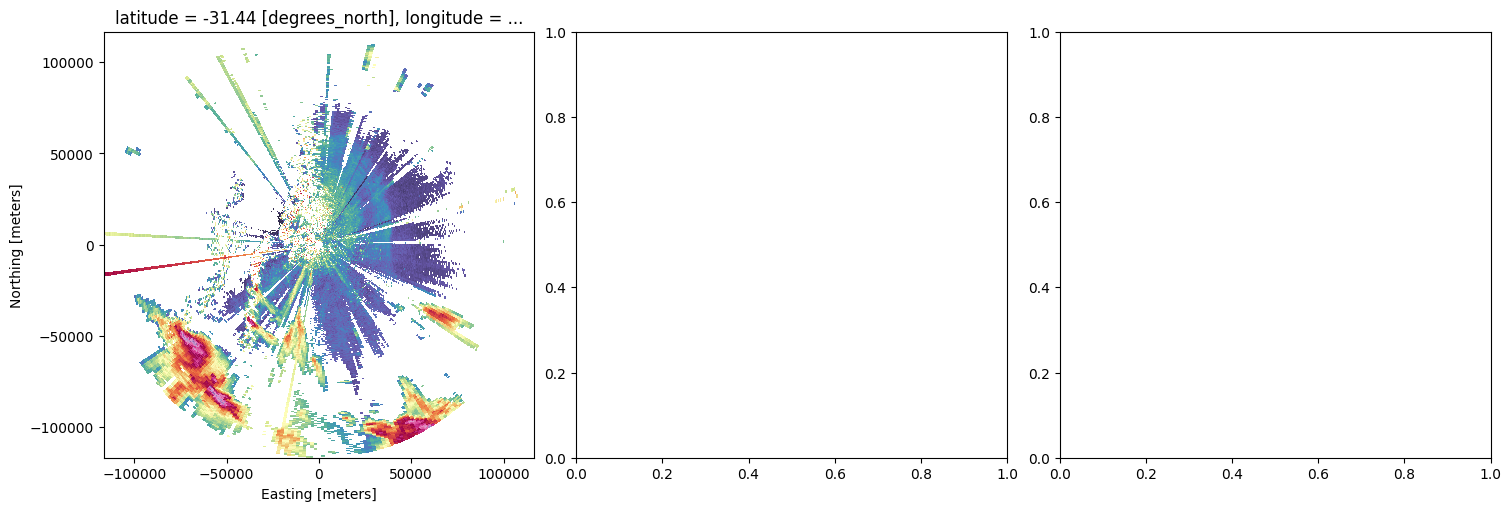

In [10]:
dtree1 = dtree1.xradar.georeference()

import cmweather  # noqa — registers colormaps with matplotlib

fig, axes = plt.subplots(3, 1, figsize=(7, 18), constrained_layout=True)

for i, ax in enumerate(axes):
    sweep = f"sweep_{i}"
    ds = dtree1[sweep].ds
    elev = ds.attrs["fixed_angle"]
    dbzh = ds["DBZH"]
    dbzh.plot(
        x="x", y="y",
        vmin=-10, vmax=70,
        cmap="ChaseSpectral",
        ax=ax,
        cbar_kwargs={"label": "DBZH (dBZ)", "shrink": 0.8},
    )
    ax.set_title(f"RMA1 — {elev:.2f}° — {ds.attrs['sweep_start_time'][:19]}Z")
    ax.set_xlabel("West-East (m)")
    ax.set_ylabel("South-North (m)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

fig.suptitle("RMA1 RELAMPAGO — DBZH — 2018-11-11 00:04 UTC", fontsize=14)
plt.show()


## Dual-polarization quicklook — sweep_0

In [ ]:
import cmweather  # noqa — registers colormaps with matplotlib

ds = dtree1["sweep_0"].ds

moments = [
    ("DBZH",  -10,  70,  "ChaseSpectral", "DBZH (dBZ)"),
    ("VRADH",  -30,  30,  "NWSVel",        "VRADH (m/s)"),
    ("ZDR",     -2,   5,  "RefDiff",       "ZDR (dB)"),
    ("RHOHV",  0.6, 1.0,  "NWS_CC",       "RHOHV"),
    ("KDP",     -1,   5,  "Theodore16",   "KDP (deg/km)"),
    ("PHIDP",   0, 180,   "Wild25",        "PHIDP (deg)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

for ax, (var, vmin, vmax, cmap, label) in zip(axes.flat, moments):
    if var not in ds:
        ax.set_visible(False)
        continue
    ds[var].plot(
        x="x", y="y",
        vmin=vmin, vmax=vmax,
        cmap=cmap,
        ax=ax,
        cbar_kwargs={"label": label, "shrink": 0.8},
    )
    ax.set_title(var)
    ax.set_aspect("equal")
    ax.set_xlabel("West-East (m)")
    ax.set_ylabel("South-North (m)")
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"RMA1 — Dual-pol quicklook — sweep_0 ({ds.attrs['fixed_angle']:.2f}°) — "
    f"{ds.attrs['sweep_start_time'][:19]}Z",
    fontsize=13,
)
plt.show()


## PPI with OpenStreetMap background

Using [cartopy](https://scitools.org.uk/cartopy) with the OpenStreetMap tile provider to overlay the radar PPI on a real map.

In [ ]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.ticker as mticker

# Site location
site_lat = dtree1.attrs["latitude"]
site_lon = dtree1.attrs["longitude"]

# Max range in degrees (approx: 120 km ≈ 1.1°)
max_range_km = 120
delta_deg = max_range_km / 111.0

# OpenStreetMap tile layer
osm = cimgt.OSM()
proj = osm.crs

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": proj},
    constrained_layout=True,
)

# Set map extent around the radar site
ax.set_extent(
    [site_lon - delta_deg, site_lon + delta_deg,
     site_lat - delta_deg, site_lat + delta_deg],
    crs=ccrs.PlateCarree(),
)

# Add OSM tiles (zoom level 8 — good for ~100 km scale)
ax.add_image(osm, 8)

# Compute lat/lon from x/y using the site position
ds = dtree1["sweep_0"].ds
dbzh = ds["DBZH"].values
x_m = ds["x"].values
y_m = ds["y"].values

# Convert to lat/lon (simple flat-Earth approximation for display)
# 1 degree latitude ≈ 111,195 m; longitude scales by cos(lat)
lat_grid = site_lat + y_m / 111_195.0
lon_grid = site_lon + x_m / (111_195.0 * np.cos(np.radians(site_lat)))

# Mask below-threshold values for transparency
dbzh_plot = np.where(dbzh > 5, dbzh, np.nan)

# Plot DBZH with transparency for clean overlay
pm = ax.pcolormesh(
    lon_grid, lat_grid, dbzh_plot,
    vmin=-10, vmax=70,
    cmap="ChaseSpectral",
    alpha=0.75,
    transform=ccrs.PlateCarree(),
)

# Mark the radar site
ax.plot(
    site_lon, site_lat, "k^", markersize=10,
    transform=ccrs.PlateCarree(), label="RMA1", zorder=5,
)
ax.text(
    site_lon + 0.05, site_lat + 0.05, "RMA1",
    transform=ccrs.PlateCarree(), fontsize=11, fontweight="bold",
    color="black", zorder=5,
)

# Gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=0.5, color="gray", alpha=0.7, linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(0.5)
gl.ylocator = mticker.MultipleLocator(0.5)

# Colorbar
cbar = plt.colorbar(pm, ax=ax, orientation="vertical", shrink=0.6, pad=0.02)
cbar.set_label("DBZH (dBZ)", fontsize=12)

ax.set_title(
    f"RMA1 RELAMPAGO — DBZH — sweep_0 ({ds.attrs['fixed_angle']:.2f}°)\n"
    f"{ds.attrs['sweep_start_time'][:19]}Z — OpenStreetMap background",
    fontsize=13,
)
plt.show()

## Read a second volume and compare DBZH

The second volume (`0620`) is a surveillance scan (`scan_01`) with more sweeps and longer range.

In [ ]:
dtree2 = open_argentina_bufr_datatree(vol2_path)
dtree2 = dtree2.xradar.georeference()

print(f"Volume 1 ({vol1_path.name}): {len(list(dtree1.children))} sweeps")
print(f"Volume 2 ({vol2_path.name}): {len(list(dtree2.children))} sweeps")
print()
for k in dtree2.children:
    elev = dtree2[k].ds.attrs['fixed_angle']
    n_bins = dtree2[k].ds.sizes['range']
    print(f"  {k}: {elev:.2f}° — {n_bins} bins")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, (dtree, label) in zip(axes, [
    (dtree1, "00:04Z — scan_02 (Doppler)"),
    (dtree2, "00:06Z — scan_01 (surveillance)"),
]):
    ds = dtree["sweep_0"].ds
    ds["DBZH"].plot(
        x="x", y="y",
        vmin=-10, vmax=70,
        cmap="ChaseSpectral",
        ax=ax,
        cbar_kwargs={"label": "DBZH (dBZ)"},
    )
    ax.set_title(f"RMA1 — {label}
{ds.attrs['fixed_angle']:.2f}° elevation")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

fig.suptitle("RMA1 RELAMPAGO — DBZH sweep_0 comparison — 2018-11-11", fontsize=13)
plt.show()


## DBZH — vol2 surveillance scan (15 sweeps)

The surveillance scan covers 0.51°–30° in 15 elevations. A 5×3 grid shows all sweeps.

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(15, 22), constrained_layout=True)

n_sweeps = len(list(dtree2.children))
for i, ax in enumerate(axes.flat):
    if i >= n_sweeps:
        ax.set_visible(False)
        continue
    ds = dtree2[f"sweep_{i}"].ds
    elev = ds.attrs["fixed_angle"]
    ds["DBZH"].plot(
        x="x", y="y",
        vmin=-10, vmax=70,
        cmap="ChaseSpectral",
        ax=ax,
        add_colorbar=(i == n_sweeps - 1),
        **(dict(cbar_kwargs={"label": "DBZH (dBZ)", "shrink": 0.6}) if i == n_sweeps - 1 else {}),
    )
    ax.set_title(f"{elev:.2f}°", fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, alpha=0.3)

fig.suptitle("RMA1 RELAMPAGO — DBZH — scan_01 (surveillance) — 2018-11-11 00:06 UTC", fontsize=13)
plt.show()


## Load only specific moments

To speed up loading you can request a subset of moments.

In [ ]:
dtree_zh_v = open_argentina_bufr_datatree(
    vol1_path,
    moments=["DBZH", "VRADH"],
)
print("Moments loaded:", sorted(dtree_zh_v["sweep_0"].ds.data_vars))

## Single-file access via xarray engine

You can also open a single `.BUFR.gz` file directly using the `argentina_bufr` xarray backend.

In [ ]:
dbzh_file = next(vol1_path.glob("*_DBZH_*.BUFR.gz"))
print("Opening:", dbzh_file.name)

ds_single = xr.open_dataset(dbzh_file, engine=ArgentinaBufrBackendEntrypoint, group="sweep_0")
ds_single

In [ ]:
# Range profile at a fixed azimuth
az_target = 270.0  # degrees (West)

fig, ax = plt.subplots(figsize=(10, 4))

for i in range(3):
    dbzh_file_i = next(vol1_path.glob("*_DBZH_*.BUFR.gz"))
    ds_i = xr.open_dataset(dbzh_file_i, engine=ArgentinaBufrBackendEntrypoint, group=f"sweep_{i}")
    profile = ds_i["DBZH"].sel(azimuth=az_target, method="nearest")
    elev = float(ds_i.elevation.mean())
    ax.plot(
        ds_i["range"] / 1000.0,
        profile,
        label=f"sweep_{i} ({elev:.2f}°)",
        lw=1.5,
    )
    ds_i.close()

ax.set_xlabel("Range (km)")
ax.set_ylabel("DBZH (dBZ)")
ax.set_title(f"RMA1 — Range profiles at azimuth ≈ {az_target:.0f}° (West)")
ax.set_xlim(0, 115)
ax.set_ylim(-15, 70)
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

- **`open_argentina_bufr_datatree(path)`** — opens a full volume (directory of `.BUFR.gz` files) into an xarray `DataTree`
- **`xr.open_dataset(file, engine=ArgentinaBufrBackendEntrypoint, group="sweep_N")`** — opens a single moment file for one sweep
- Sweeps from different moment files are merged by matching **elevation angle** (±0.1° tolerance)
- Moments with different range resolutions are **padded with NaN** to a common range dimension
- The `moments=` argument lets you load only a subset of moments for faster I/O
- Use `dtree.xradar.georeference()` to add x/y/z coordinates for Cartesian plotting

## Pseudo-RHI at 235°

Use pyart`s `RadarDisplay.plot_azimuth_to_rhi` on the surveillance scan.

In [ ]:
import pyart
import cmweather  # noqa

# Convert xradar DataTree → pyart Radar
radar2 = dtree2.pyart.to_radar()

display = pyart.graph.RadarDisplay(radar2)

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
display.plot_azimuth_to_rhi(
    "DBZH", 235,
    vmin=-10, vmax=70,
    cmap="ChaseSpectral",
    ax=ax,
    colorbar_label="DBZH (dBZ)",
    title=f"RMA1 RELAMPAGO — Pseudo-RHI 235° — 2018-11-11 00:06 UTC (scan_01)",
)
ax.set_ylim(0, 15)
ax.set_xlim(0, 200)
ax.grid(True, alpha=0.3)
plt.show()
